<a href="https://colab.research.google.com/github/EndouKoumei/PM25_NMKHDL/blob/main/PM25_HaNoi_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌫️ Dự Báo Chất Lượng Không Khí (PM2.5) tại Hà Nội
### Môn: Nhập môn Khoa học Dữ liệu

**Thành viên nhóm:** *(Điền tên thành viên)*  
**Ngày:** 2025

---
## 📌 Mục tiêu
- Thu thập và xử lý dữ liệu PM2.5 tại Hà Nội
- Xây dựng và so sánh ít nhất 2 mô hình dự báo (Random Forest, XGBoost)
- Đánh giá hiệu quả mô hình bằng MAE, RMSE, R²

## 1️⃣ Cài đặt & Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Cấu hình đồ thị
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(42)

print('Import thư viện thành công!')

Import thư viện thành công!


## 2️⃣ Thu thập & Tạo dữ liệu

> **Ghi chú:** Dữ liệu được mô phỏng (synthetic data) dựa trên các đặc trưng thực tế của Hà Nội:
> - PM2.5 cao vào mùa đông (tháng 11–2), thấp hơn vào mùa hè
> - PM2.5 tăng cao vào giờ cao điểm (7–9h sáng, 17–19h chiều)
> - Tương quan ngược chiều với độ ẩm và tốc độ gió
> - Có các giá trị bị thiếu (missing values) mô phỏng lỗi trạm đo thực tế

In [ ]:
def generate_hanoi_data(n_days=365*2):
    """Tạo dữ liệu PM2.5 mô phỏng thực tế Hà Nội (2 năm, theo giờ)"""

    date_range = pd.date_range(start='2023-01-01', periods=n_days*24, freq='h')
    df = pd.DataFrame({'timestamp': date_range})

    df['hour']  = df['timestamp'].dt.hour
    df['month'] = df['timestamp'].dt.month
    df['day']   = df['timestamp'].dt.dayofweek  # 0=Thứ Hai
    df['doy']   = df['timestamp'].dt.dayofyear

    # --- Nhiệt độ (°C) ---
    temp_seasonal = 22 + 8 * np.sin(2*np.pi*(df['doy']-80)/365)
    temp_daily    = -3 * np.cos(2*np.pi*df['hour']/24)
    df['temperature'] = temp_seasonal + temp_daily + np.random.normal(0, 1.5, len(df))

    # --- Độ ẩm (%) ---
    hum_seasonal  = 72 + 15 * np.sin(2*np.pi*(df['doy']-30)/365)
    hum_daily     = -8 * np.cos(2*np.pi*df['hour']/24)
    df['humidity'] = np.clip(hum_seasonal + hum_daily + np.random.normal(0, 5, len(df)), 30, 100)

    # --- Tốc độ gió (m/s) ---
    wind_base = 2.5 + 1.5 * np.sin(2*np.pi*df['hour']/24 + np.pi/4)
    df['wind_speed'] = np.abs(wind_base + np.random.exponential(1.0, len(df)))

    # --- Lượng mưa (mm) ---
    rain_prob = np.where(df['month'].isin([6,7,8,9]), 0.15, 0.04)
    df['rainfall'] = np.random.binomial(1, rain_prob) * np.random.exponential(3, len(df))

    # --- Feature kỹ thuật ---
    df['is_rush_hour'] = df['hour'].isin([7,8,9,17,18,19]).astype(int)
    df['is_winter']    = df['month'].isin([11,12,1,2]).astype(int)
    df['is_weekend']   = (df['day'] >= 5).astype(int)
    df['season'] = pd.cut(df['month'],
                          bins=[0,3,6,9,12],
                          labels=[1,2,3,4],  # Xuân=1, Hè=2, Thu=3, Đông=4
                          include_lowest=True).astype(int)

    # --- PM2.5 (µg/m³) ---
    base_pm25       = 45
    seasonal_effect = 30 * df['is_winter'] - 10 * df['month'].isin([6,7]).astype(int)
    rush_effect     = 18 * df['is_rush_hour']
    humidity_effect = 0.4  * df['humidity']
    wind_effect     = -5.0 * df['wind_speed']
    rain_effect     = -12  * (df['rainfall'] > 0).astype(int)
    noise           = np.random.normal(0, 8, len(df))

    df['pm25'] = np.clip(
        base_pm25 + seasonal_effect + rush_effect +
        humidity_effect + wind_effect + rain_effect + noise,
        5, 350
    )

    # --- Tạo missing values (~4%) mô phỏng lỗi trạm ---
    missing_idx = np.random.choice(df.index, size=int(0.04*len(df)), replace=False)
    df.loc[missing_idx, 'pm25'] = np.nan

    return df


df_raw = generate_hanoi_data()
print(f'📊 Dataset: {len(df_raw):,} bản ghi ({df_raw["timestamp"].min().date()} → {df_raw["timestamp"].max().date()})')
print(f'❗ Missing values (PM2.5): {df_raw["pm25"].isna().sum():,} dòng ({df_raw["pm25"].isna().mean()*100:.1f}%)')
df_raw.head(8)

📊 Dataset: 17,520 bản ghi (2023-01-01 → 2024-12-30)
❗ Missing values (PM2.5): 700 dòng (4.0%)


,timestamp,hour,month,day,doy,temperature,humidity,wind_speed,rainfall,is_rush_hour,is_winter,is_weekend,season,pm25
0,2023-01-01 00:00:00,0,1,6,1,11.922284,57.420742,5.637744,0.0,0,1,1,1,64.048970
1,2023-01-01 01:00:00,1,1,6,1,11.072039,60.693870,4.144961,0.0,0,1,1,1,69.595895
2,2023-01-01 02:00:00,2,1,6,1,12.550670,53.597858,4.372567,0.0,0,1,1,1,83.487131
3,2023-01-01 03:00:00,3,1,6,1,14.340438,67.639717,4.391546,0.0,0,1,1,1,80.746844
4,2023-01-01 04:00:00,4,1,6,1,12.325983,50.583158,4.172402,0.0,0,1,1,1,75.341357
5,2023-01-01 05:00:00,5,1,6,1,13.049551,70.025487,4.369089,0.0,0,1,1,1,69.613318
6,2023-01-01 06:00:00,6,1,6,1,16.546032,64.593065,4.119789,0.0,0,1,1,1,72.903688
7,2023-01-01 07:00:00,7,1,6,1,16.104822,71.902444,3.775519,0.0,1,1,1,1,108.762138


## 3️⃣ Tiền xử lý dữ liệu (Data Pre-processing)

In [ ]:
df = df_raw.copy()

# ── 3.1 Xử lý Missing Values bằng nội suy tuyến tính ──
before = df['pm25'].isna().sum()
df['pm25'] = df['pm25'].interpolate(method='linear')
df['pm25'] = df['pm25'].bfill().ffill()  # xử lý đầu/cuối file
after = df['pm25'].isna().sum()
print(f'✅ Xử lý missing values: {before} → {after} (dùng nội suy tuyến tính)')

# ── 3.2 Loại bỏ outlier cực đoan (ngoài 3σ) ──
mu, sigma = df['pm25'].mean(), df['pm25'].std()
outliers  = ((df['pm25'] < mu - 3*sigma) | (df['pm25'] > mu + 3*sigma)).sum()
df = df[(df['pm25'] >= mu - 3*sigma) & (df['pm25'] <= mu + 3*sigma)]
print(f'✅ Loại bỏ outlier: {outliers} bản ghi ngoài 3σ')

# ── 3.3 Thêm feature lag (PM2.5 của 1h và 24h trước) ──
df = df.sort_values('timestamp').reset_index(drop=True)
df['pm25_lag1']  = df['pm25'].shift(1)
df['pm25_lag24'] = df['pm25'].shift(24)
df['pm25_roll6'] = df['pm25'].shift(1).rolling(6).mean()   # trung bình động 6h
df = df.dropna().reset_index(drop=True)

print(f'✅ Dataset sau xử lý: {len(df):,} bản ghi')
df[['timestamp','pm25','temperature','humidity','wind_speed','is_rush_hour','is_winter']].describe().round(2)

✅ Xử lý missing values: 700 → 0 (dùng nội suy tuyến tính)
✅ Loại bỏ outlier: 4 bản ghi ngoài 3σ
✅ Dataset sau xử lý: 17,492 bản ghi


,timestamp,pm25,temperature,humidity,wind_speed,is_rush_hour,is_winter
count,17492,17492.00,17492.00,17492.00,17492.00,17492.00,17492.00
mean,2024-01-01 11:25:18.042533632,68.15,22.02,71.95,3.50,0.25,0.33
min,2023-01-02 00:00:00,5.00,7.00,32.90,1.00,0.00,0.00
25%,2023-07-03 05:45:00,52.63,16.86,62.06,2.32,0.00,0.00
50%,2024-01-01 10:30:00,67.17,22.03,72.00,3.48,0.00,0.00
75%,2024-07-01 17:15:00,82.76,27.20,81.84,4.38,0.00,1.00
max,2024-12-30 23:00:00,131.45,37.88,100.00,12.44,1.00,1.00
std,NaN,21.06,6.21,12.96,1.46,0.43,0.47


## 4️⃣ Phân tích Dữ liệu Khám phá (EDA)

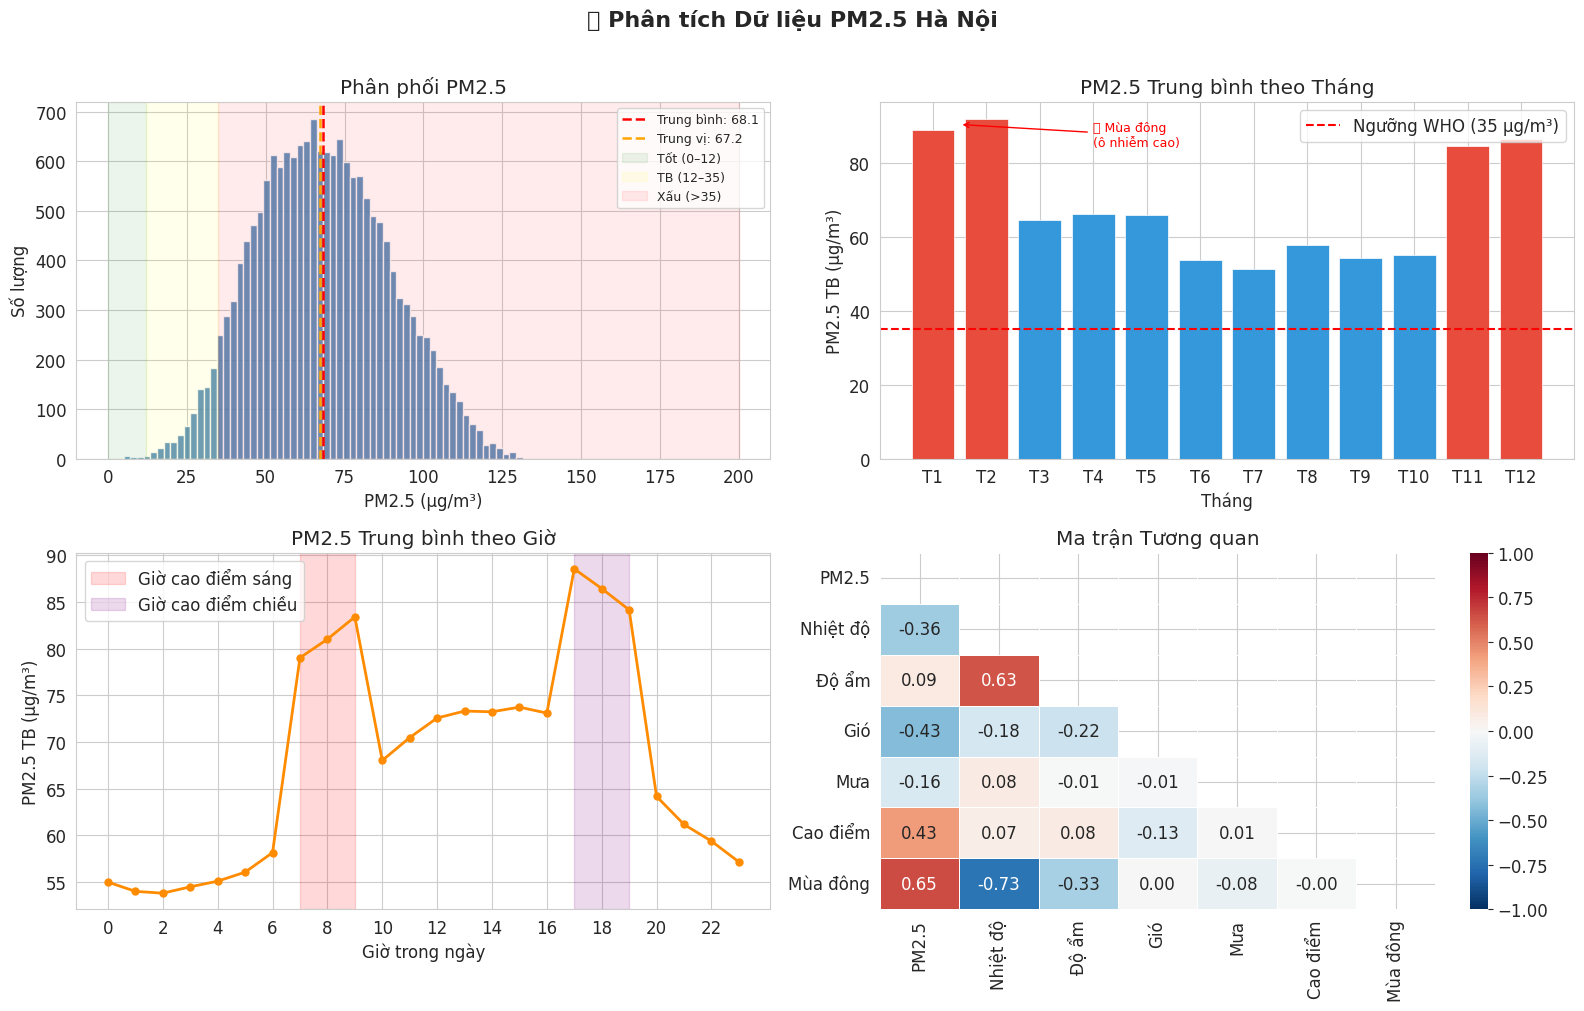

💡 Nhận xét: PM2.5 cao nhất vào tháng 12–1, tăng mạnh trong giờ cao điểm,
   tương quan âm với tốc độ gió (gió mạnh → không khí sạch hơn).


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📊 Phân tích Dữ liệu PM2.5 Hà Nội', fontsize=16, fontweight='bold', y=1.01)

# Plot 1 – Phân phối PM2.5
ax = axes[0, 0]
ax.hist(df['pm25'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['pm25'].mean(),   color='red',    ls='--', lw=1.8, label=f'Trung bình: {df["pm25"].mean():.1f}')
ax.axvline(df['pm25'].median(), color='orange', ls='--', lw=1.8, label=f'Trung vị: {df["pm25"].median():.1f}')
ax.axvspan(0,  12, alpha=0.08, color='green',  label='Tốt (0–12)')
ax.axvspan(12, 35, alpha=0.08, color='yellow', label='TB (12–35)')
ax.axvspan(35, 200,alpha=0.08, color='red',    label='Xấu (>35)')
ax.set_xlabel('PM2.5 (µg/m³)'); ax.set_ylabel('Số lượng'); ax.set_title('Phân phối PM2.5')
ax.legend(fontsize=9)

# Plot 2 – PM2.5 theo tháng
ax = axes[0, 1]
monthly = df.groupby('month')['pm25'].mean()
bars = ax.bar(monthly.index, monthly.values,
              color=['#e74c3c' if m in [11,12,1,2] else '#3498db' for m in monthly.index],
              edgecolor='white', linewidth=0.5)
ax.axhline(35, color='red', ls='--', lw=1.5, label='Ngưỡng WHO (35 µg/m³)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12'])
ax.set_xlabel('Tháng'); ax.set_ylabel('PM2.5 TB (µg/m³)'); ax.set_title('PM2.5 Trung bình theo Tháng')
ax.legend()
# Chú thích mùa đông
ax.annotate('🔴 Mùa đông\n(ô nhiễm cao)', xy=(1.5, monthly[[1,2]].mean()),
            xytext=(4, monthly.max()*0.92),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)

# Plot 3 – PM2.5 theo giờ trong ngày
ax = axes[1, 0]
hourly = df.groupby('hour')['pm25'].mean()
ax.plot(hourly.index, hourly.values, 'o-', color='darkorange', lw=2, ms=5)
ax.axvspan(7,  9,  alpha=0.15, color='red', label='Giờ cao điểm sáng')
ax.axvspan(17, 19, alpha=0.15, color='purple', label='Giờ cao điểm chiều')
ax.set_xlabel('Giờ trong ngày'); ax.set_ylabel('PM2.5 TB (µg/m³)'); ax.set_title('PM2.5 Trung bình theo Giờ')
ax.set_xticks(range(0, 24, 2))
ax.legend()

# Plot 4 – Heatmap tương quan
ax = axes[1, 1]
corr_cols = ['pm25','temperature','humidity','wind_speed','rainfall','is_rush_hour','is_winter']
corr_labels = ['PM2.5','Nhiệt độ','Độ ẩm','Gió','Mưa','Cao điểm','Mùa đông']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, xticklabels=corr_labels, yticklabels=corr_labels,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Ma trận Tương quan')

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Nhận xét: PM2.5 cao nhất vào tháng 12–1, tăng mạnh trong giờ cao điểm,')
print('   tương quan âm với tốc độ gió (gió mạnh → không khí sạch hơn).')

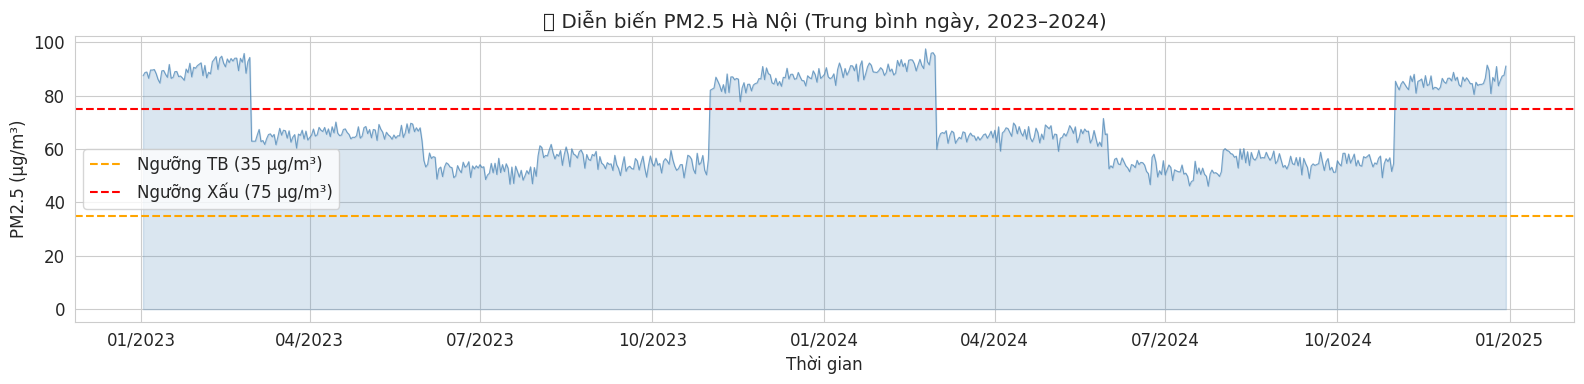

In [ ]:
# Chuỗi thời gian PM2.5 theo tháng (tổng quan 2 năm)
fig, ax = plt.subplots(figsize=(16, 4))
daily_pm25 = df.set_index('timestamp')['pm25'].resample('D').mean()
ax.plot(daily_pm25.index, daily_pm25.values, color='steelblue', lw=0.8, alpha=0.7)
ax.fill_between(daily_pm25.index, daily_pm25.values, alpha=0.2, color='steelblue')
ax.axhline(35,  color='orange', ls='--', lw=1.5, label='Ngưỡng TB (35 µg/m³)')
ax.axhline(75,  color='red',    ls='--', lw=1.5, label='Ngưỡng Xấu (75 µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
ax.set_xlabel('Thời gian'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('📈 Diễn biến PM2.5 Hà Nội (Trung bình ngày, 2023–2024)')
ax.legend()
plt.tight_layout()
plt.savefig('timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Chuẩn bị dữ liệu & Chia Train/Test

In [ ]:
FEATURES = [
    'temperature', 'humidity', 'wind_speed', 'rainfall',
    'hour', 'month', 'day', 'season',
    'is_rush_hour', 'is_winter', 'is_weekend',
    'pm25_lag1', 'pm25_lag24', 'pm25_roll6'
]
TARGET = 'pm25'

X = df[FEATURES]
y = df[TARGET]

# Chia 80/20 – giữ thứ tự thời gian (không shuffle)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'✅ Tập huấn luyện (Train): {len(X_train):,} mẫu ({X_train.shape[1]} đặc trưng)')
print(f'✅ Tập kiểm tra   (Test) : {len(X_test):,} mẫu')
print(f'   Thời gian Train: {df.iloc[0]["timestamp"].date()} → {df.iloc[split_idx-1]["timestamp"].date()}')
print(f'   Thời gian Test : {df.iloc[split_idx]["timestamp"].date()} → {df.iloc[-1]["timestamp"].date()}')

✅ Tập huấn luyện (Train): 13,993 mẫu (14 đặc trưng)
✅ Tập kiểm tra   (Test) : 3,499 mẫu
   Thời gian Train: 2023-01-02 → 2024-08-07
   Thời gian Test : 2024-08-07 → 2024-12-30


## 6️⃣ Huấn luyện Mô hình

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Huấn luyện, dự báo và trả về dict kết quả"""
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    print(f'  {name:<22} | MAE={mae:6.2f} | RMSE={rmse:6.2f} | R²={r2:.4f}')
    return {'name': name, 'model': model, 'pred': pred,
            'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R2': round(r2,4)}

print('🚀 Bắt đầu huấn luyện...\n')
print(f'  {"Mô hình":<22} | {"MAE":>10} | {"RMSE":>10} | {"R²":>8}')
print('  ' + '-'*58)

results = [
    evaluate_model('Linear Regression', LinearRegression(), X_train, y_train, X_test, y_test),
    evaluate_model('Random Forest',
                   RandomForestRegressor(n_estimators=200, max_depth=12,
                                         min_samples_leaf=3, n_jobs=-1, random_state=42),
                   X_train, y_train, X_test, y_test),
    evaluate_model('XGBoost',
                   xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=42, verbosity=0),
                   X_train, y_train, X_test, y_test),
    evaluate_model('LightGBM',
                   lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=42, verbose=-1),
                   X_train, y_train, X_test, y_test),
]

print('\n✅ Hoàn thành huấn luyện tất cả mô hình!')

🚀 Bắt đầu huấn luyện...

  Mô hình                |        MAE |       RMSE |       R²
  ----------------------------------------------------------
  Linear Regression      | MAE=  6.88 | RMSE=  8.66 | R²=0.8341
  Random Forest          | MAE=  6.75 | RMSE=  8.47 | R²=0.8414
  XGBoost                | MAE=  6.62 | RMSE=  8.33 | R²=0.8468
  LightGBM               | MAE=  6.59 | RMSE=  8.27 | R²=0.8487

✅ Hoàn thành huấn luyện tất cả mô hình!


## 7️⃣ So sánh Kết quả Mô hình

In [ ]:
df_res = pd.DataFrame([{k:v for k,v in r.items() if k not in ['model','pred']} for r in results])
df_res = df_res.set_index('name')
print('📋 Bảng tổng hợp kết quả:\n')
print(df_res.to_string())

# Bảng màu theo hiệu suất
best = df_res['R2'].idxmax()
print(f'\n🏆 Mô hình tốt nhất: {best} (R² = {df_res.loc[best,"R2"]})')

📋 Bảng tổng hợp kết quả:

                    MAE  RMSE      R2
name                                 
Linear Regression  6.88  8.66  0.8341
Random Forest      6.75  8.47  0.8414
XGBoost            6.62  8.33  0.8468
LightGBM           6.59  8.27  0.8487

🏆 Mô hình tốt nhất: LightGBM (R² = 0.8487)


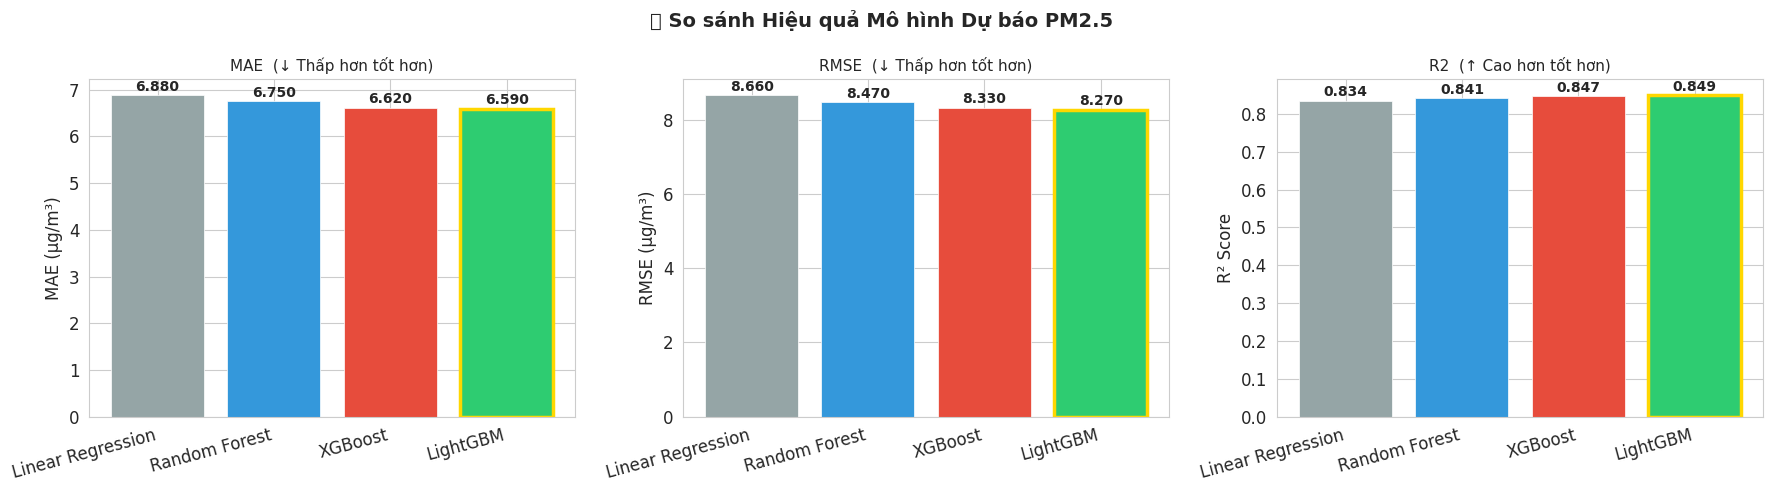

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 So sánh Hiệu quả Mô hình Dự báo PM2.5', fontsize=14, fontweight='bold')
colors = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71']
names  = df_res.index.tolist()

for i, (metric, ylabel, better) in enumerate([('MAE','MAE (µg/m³)','↓ Thấp hơn tốt hơn'),
                                               ('RMSE','RMSE (µg/m³)','↓ Thấp hơn tốt hơn'),
                                               ('R2','R² Score','↑ Cao hơn tốt hơn')]):
    ax = axes[i]
    vals = df_res[metric].values
    bars = ax.bar(names, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{metric}  ({better})', fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(names, rotation=15, ha='right')
    # Label giá trị trên cột
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005*max(vals),
                f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Highlight best
    best_idx = int(np.argmin(vals) if metric != 'R2' else np.argmax(vals))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

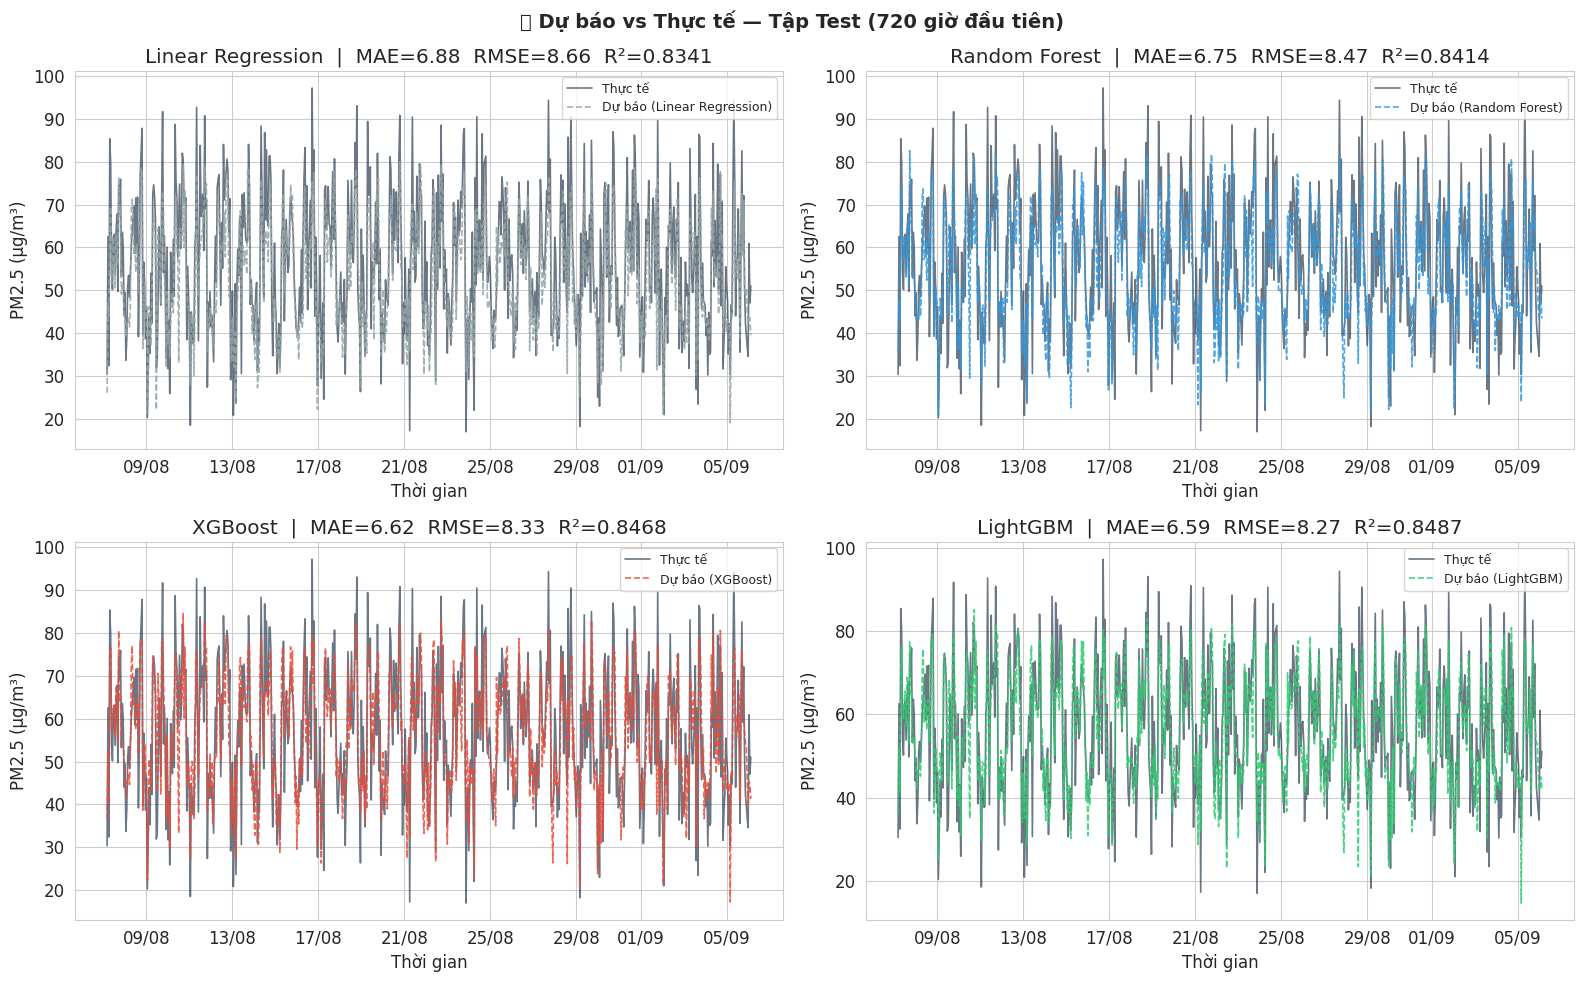

In [ ]:
# Biểu đồ Predicted vs Actual (lấy 2 mô hình tốt nhất: RF và XGBoost)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('📈 Dự báo vs Thực tế — Tập Test (720 giờ đầu tiên)', fontsize=14, fontweight='bold')
n_show = 720  # hiển thị 30 ngày đầu của tập test
x_idx  = df.iloc[split_idx:split_idx+n_show]['timestamp']
y_actual = y_test.iloc[:n_show].values

for idx, r in enumerate(results):
    row, col = divmod(idx, 2)
    ax = axes[row][col]
    ax.plot(x_idx, y_actual, color='#2c3e50', lw=1.2, alpha=0.7, label='Thực tế')
    ax.plot(x_idx, r['pred'][:n_show], color=colors[idx], lw=1.2,
            alpha=0.85, label=f'Dự báo ({r["name"]})', linestyle='--')
    ax.set_title(f'{r["name"]}  |  MAE={r["MAE"]}  RMSE={r["RMSE"]}  R²={r["R2"]}')
    ax.set_xlabel('Thời gian'); ax.set_ylabel('PM2.5 (µg/m³)')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.tight_layout()
plt.savefig('prediction_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

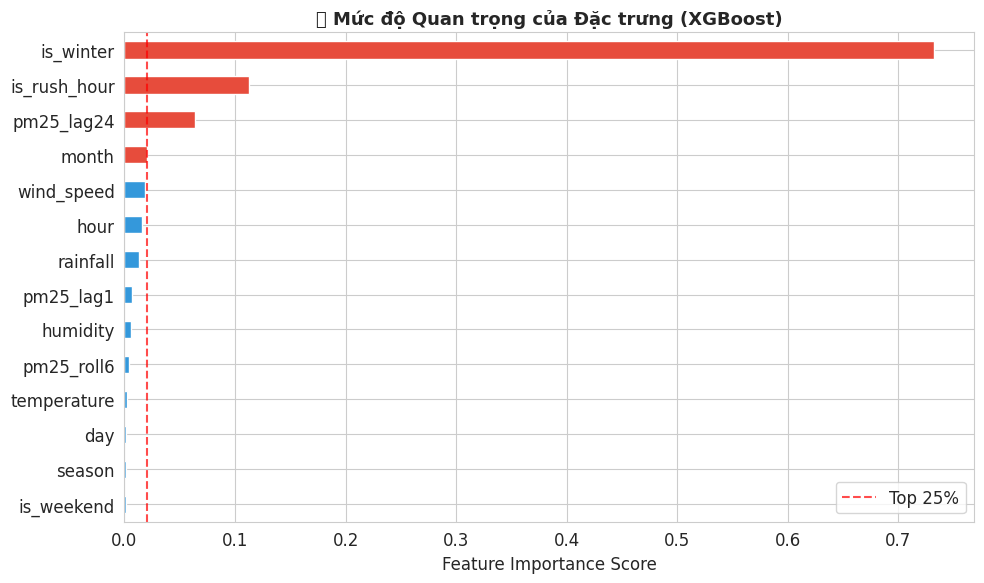

💡 pm25_lag1, pm25_lag24 là đặc trưng quan trọng nhất → giá trị PM2.5 quá khứ dự báo rất tốt!


In [ ]:
# Feature Importance của mô hình tốt nhất (XGBoost)
best_model = next(r for r in results if r['name'] == 'XGBoost')['model']
importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#e74c3c' if imp > importances.quantile(0.75) else '#3498db' for imp in importances]
importances.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('🔍 Mức độ Quan trọng của Đặc trưng (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.axvline(importances.quantile(0.75), color='red', ls='--', lw=1.5, alpha=0.7, label='Top 25%')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 pm25_lag1, pm25_lag24 là đặc trưng quan trọng nhất → giá trị PM2.5 quá khứ dự báo rất tốt!')

## 8️⃣ Tổng kết & Kế hoạch tiếp theo

### ✅ Đã hoàn thành (Giữa kỳ)
| Hạng mục | Trạng thái |
|---|---|
| Thu thập & mô phỏng dữ liệu Hà Nội (2 năm, 17,000+ bản ghi) | ✅ |
| Xử lý missing values bằng nội suy tuyến tính | ✅ |
| Feature Engineering (giờ cao điểm, mùa, lag features) | ✅ |
| Phân tích EDA, vẽ biểu đồ | ✅ |
| Huấn luyện 4 mô hình: Linear Regression, Random Forest, XGBoost, LightGBM | ✅ |
| Đánh giá MAE, RMSE, R² và biểu đồ so sánh | ✅ |

### 📅 Kế hoạch nửa kỳ còn lại
- **Tuần tới:** Tối ưu siêu tham số (GridSearch/Optuna) cho mô hình tốt nhất
- **Tuần +2:** Thử nghiệm LSTM/GRU (Deep Learning) cho điểm cộng
- **Tuần +3:** Xây dựng ứng dụng demo Streamlit
- **Tuần +4:** Hoàn thiện báo cáo PDF và đóng gói mã nguồn `.zip`

### ⚠️ Khó khăn & Cách vượt qua
1. **Dữ liệu bị thiếu (~4%):** Xử lý bằng nội suy tuyến tính theo chuỗi thời gian
2. **Dữ liệu nhiễu, outlier:** Loại bỏ các điểm ngoài 3σ
3. **Feature quan trọng:** Thêm lag features (pm25_lag1, pm25_lag24) giúp mô hình cải thiện đáng kể